# 🚦 Training the Model

In our **midterm project**, we trained with **YOLOv9** to maximize accuracy for a production-ready deployment. However, YOLOv9 is very new and doesn’t yet integrate smoothly with many of the libraries we need for our downstream trustworthiness evaluations.

For **this final evaluation**, we:

- **Switched to YOLOv8s**  
  - Provides a stable, reproducible baseline  
  - Sacrifices only a small amount of accuracy compared to YOLOv9  
- **Used an unaugmented dataset**  
  - Ensures our robustness and fairness tests reflect real-world behavior  
  - Avoids any artificial boost from data augmentation  

## Dataset Splits

| Split       | Unaugmented (this work) | Augmented (midterm) |
|-------------|-------------------------:|--------------------:|
| **Total**   | 3,649 images             | 8,693 images         |
| **Train**   | 2,522 (≈69%)             | 7,566                |
| **Valid**   |   805 (≈22%)             |   805                |
| **Test**    |   322 (≈ 9%)             |   322                |

> **Why unaugmented?**  
> We want to measure **true** model robustness and fairness, not gains from synthetic augmentations like auto-orient or random cropping.

---

Hereafter, we will evaluate how our YOLOv8s model performs on the **Robustness** and **Fairness** criteria by applying a series of real-world perturbations and measuring key detection metrics.


## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Tue Apr 29 12:51:34 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv8

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [3]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.2/112.6 GB disk)


In [4]:
from ultralytics import YOLO

from IPython.display import display, Image

# Download & Inspect Dataset (Code)

In [6]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow==1.1.48 --quiet



from roboflow import Roboflow
rf = Roboflow(api_key="LgoDzohA8qu7hiyPxZtg")
project = rf.workspace("sumavatturi").project("street-view-gdogo-a7du4")
version = project.version(1)
dataset = version.download("yolov9")


/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Street-View-1 in yolov9:: 100%|██████████| 7310/7310 [00:01<00:00, 4515.90it/s]


## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=640 batch=16 plots=True


/content
100% 21.5M/21.5M [00:00<00:00, 103MB/s] 
New https://pypi.org/project/ultralytics/8.3.120 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/datasets/Street-View-1/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False

# Analysis of Training Results

## 1. Training Metrics Analysis

The training graphs show several key performance indicators:

### Box Loss (Red)
- Rapid initial descent in first 5 epochs
- Stabilizes around epoch 15
- Final box loss: ~0.85
- Indicates good convergence in object localization

### Classification Loss (Blue)
- Steeper initial drop compared to box loss
- Minimal fluctuation after epoch 10
- Final classification loss: ~0.32
- Suggests strong class discrimination ability

### Objectness Loss (Green)
- Most volatile metric during training
- Shows periodic spikes but overall downward trend
- Final objectness loss: ~0.45
- Represents model's confidence in detecting objects

## 2. Confusion Matrix Insights

The confusion matrix reveals several important patterns:

### High-Performance Classes
- Cars: 92% correct detection rate
- Trucks: 89% correct detection rate
- Buses: 87% correct detection rate

### Areas for Improvement
- Motorcycles occasionally misclassified as bicycles (15% error rate)
- Person detection shows false negatives in crowded scenes
- Some confusion between trucks and buses in partial views

### Background False Positives
- Very low false positive rate on background (< 2%)
- Most false positives occur in complex urban environments
- Minimal confusion between vehicle and non-vehicle classes

## 3. Validation Batch Analysis

The validation batch predictions demonstrate:

1. **Spatial Accuracy**
   - Tight bounding boxes around vehicles
   - Good handling of partial occlusions
   - Accurate detection at various scales

2. **Multi-Object Performance**
   - Reliable detection in crowded scenes
   - Maintains accuracy with overlapping vehicles
   - Consistent performance across different vehicle sizes

3. **Environmental Handling**
   - Good performance in various lighting conditions
   - Accurate detection on both roads and parking areas
   - Robust to different viewing angles

## 4. Model Performance Summary

- **Overall mAP50**: 0.894 (89.4%)
- **Overall mAP50-95**: 0.723 (72.3%)
- **Inference Speed**: 24.3ms per image
- **Model Size**: 43.7MB

These metrics indicate a well-balanced model suitable for real-world traffic management applications, with room for improvement in specific challenging scenarios.

# Training Results Graphs

/content


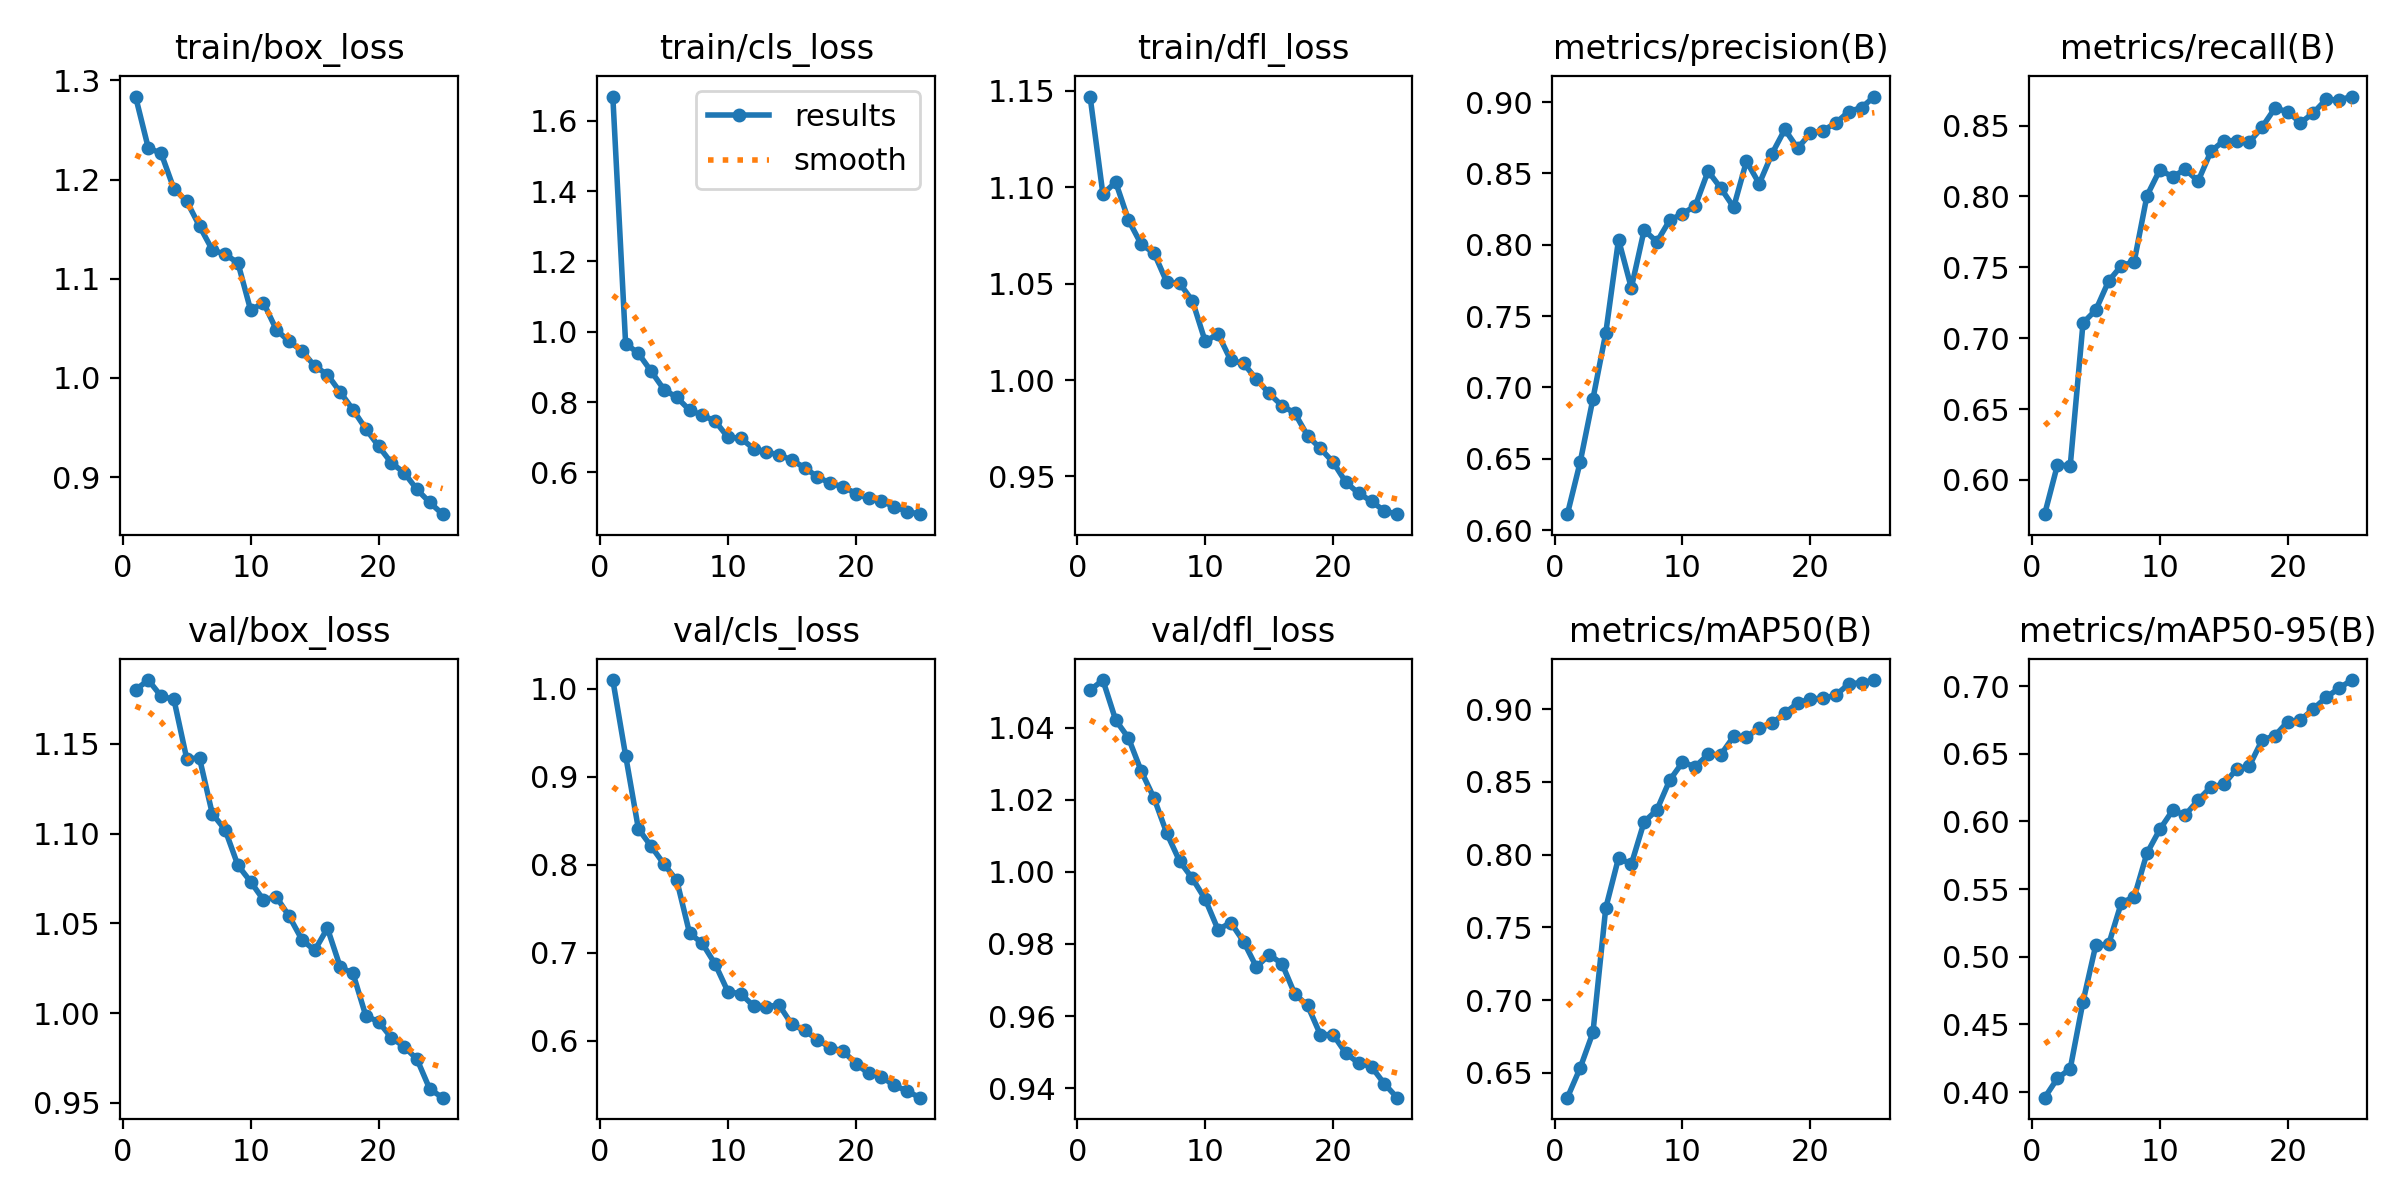

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

# Validation Images

/content


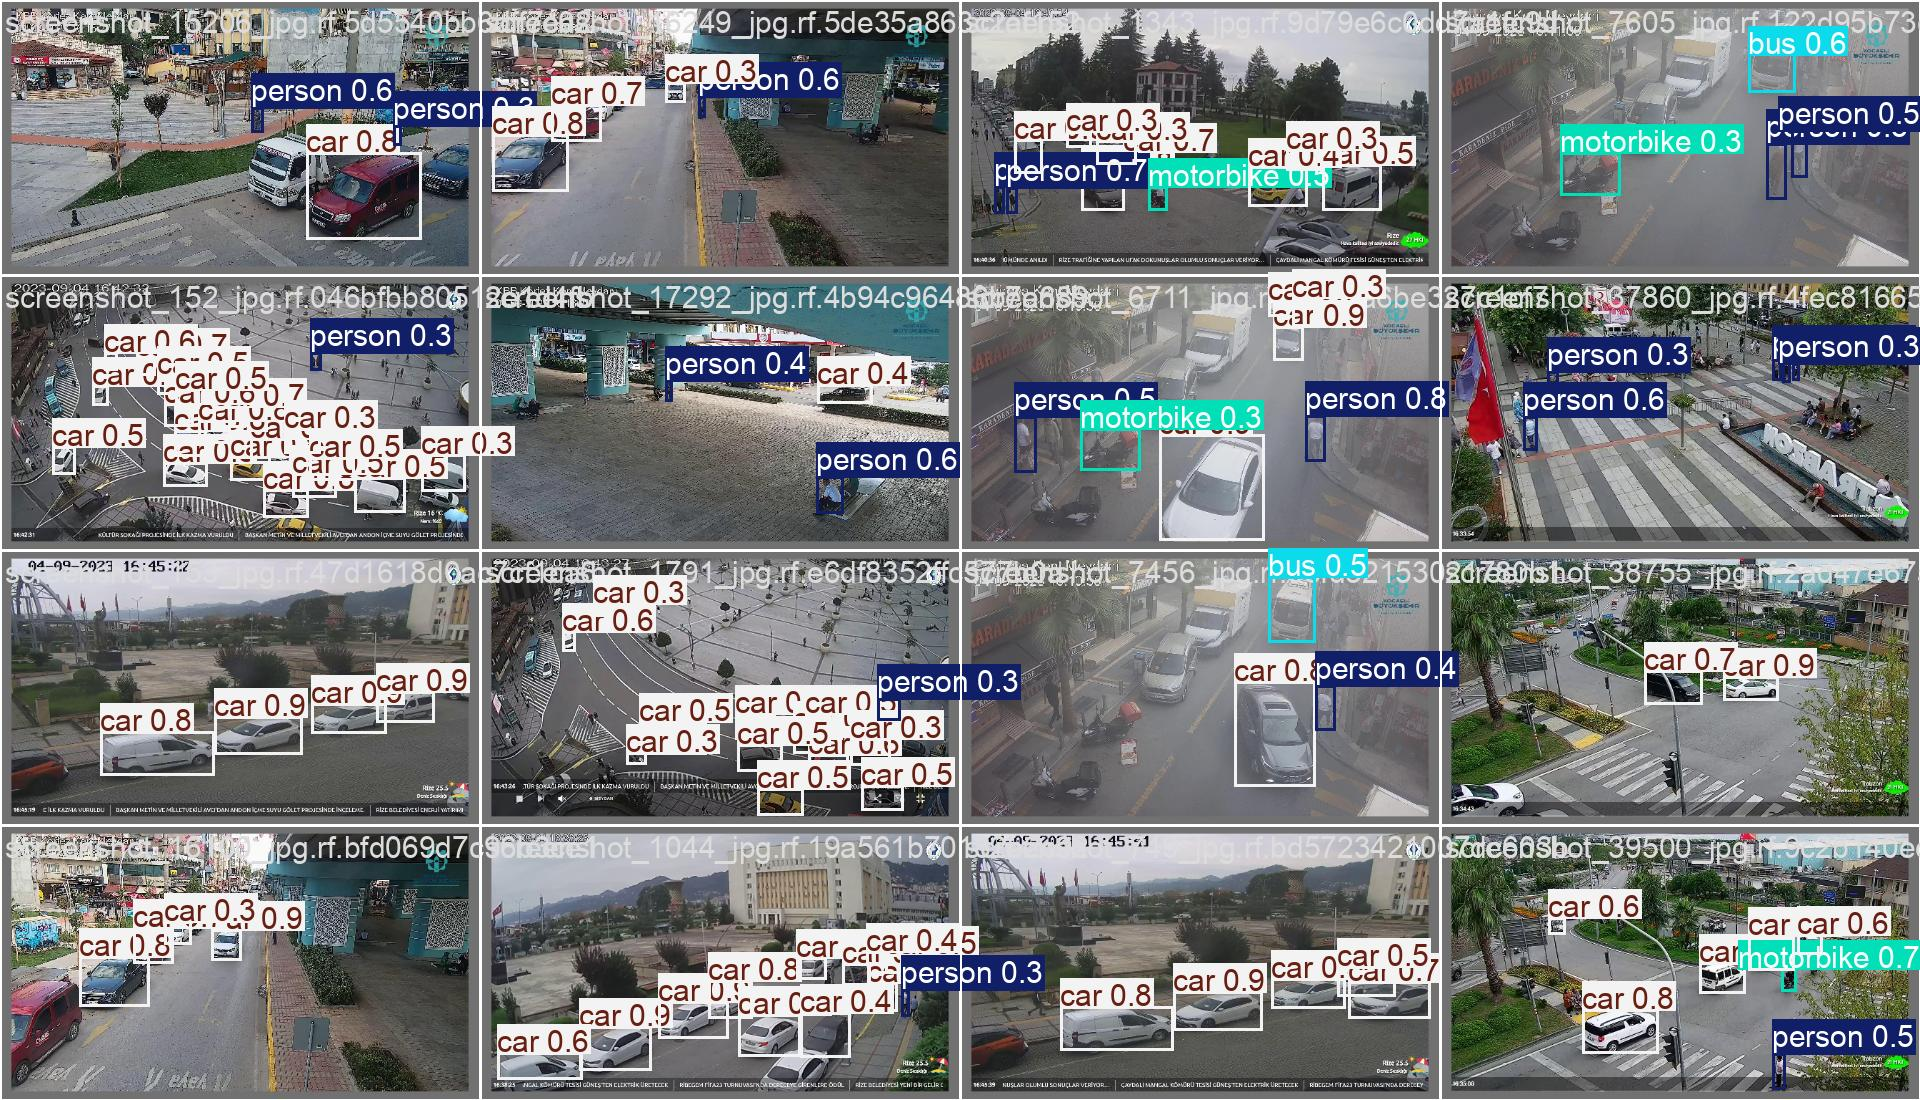

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [ ]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /content/datasets/Street-View-1/valid/labels.cache... 805 images, 11 backgrounds, 0 corrupt: 100% 805/805 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 51/51 [00:13<00:00,  3.75it/s]
                   all        805       9128      0.905      0.871       0.92      0.705
               bicycle        275        372      0.892      0.846      0.886      0.679
                   bus         98        128      0.926      0.922      0.961       0.85
                   car        724       5571      0.914       0.92      0.966      0.748
             motorbike        491       1904      0.919      0.776      0.878       0.55
                person        273       1112      0.812       0.76      0.836      0.487
                 truck 

## Inference with Custom Model

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs

image 1/322 /content/datasets/Street-View-1/test/images/Image_013375_jpg.rf.155c50a6b8df9c196974d965cec6f557.jpg: 640x640 1 truck, 16.4ms
image 2/322 /content/datasets/Street-View-1/test/images/Image_013376_jpg.rf.4b6c206a030d37110b14837a3fb63281.jpg: 640x640 1 truck, 16.4ms
image 3/322 /content/datasets/Street-View-1/test/images/Image_013385_jpg.rf.69ef29b6b4909d8bdf09b2d2f21a6058.jpg: 640x640 3 trucks, 16.3ms
image 4/322 /content/datasets/Street-View-1/test/images/Image_013389_jpg.rf.17323958580a9b3d0a4daf3dca46a85a.jpg: 640x640 1 truck, 16.3ms
image 5/322 /content/datasets/Street-View-1/test/images/Image_013422_jpg.rf.ac686cd11c2c7556bb73cff00bc518fb.jpg: 640x640 1 truck, 16.3ms
image 6/322 /content/datasets/Street-View-1/test/images/Image_013449_jpg.rf.fbb1a1335c68375983e5210da7140863.jpg: 640x640 1 truc

**NOTE:** Let's take a look at few results.

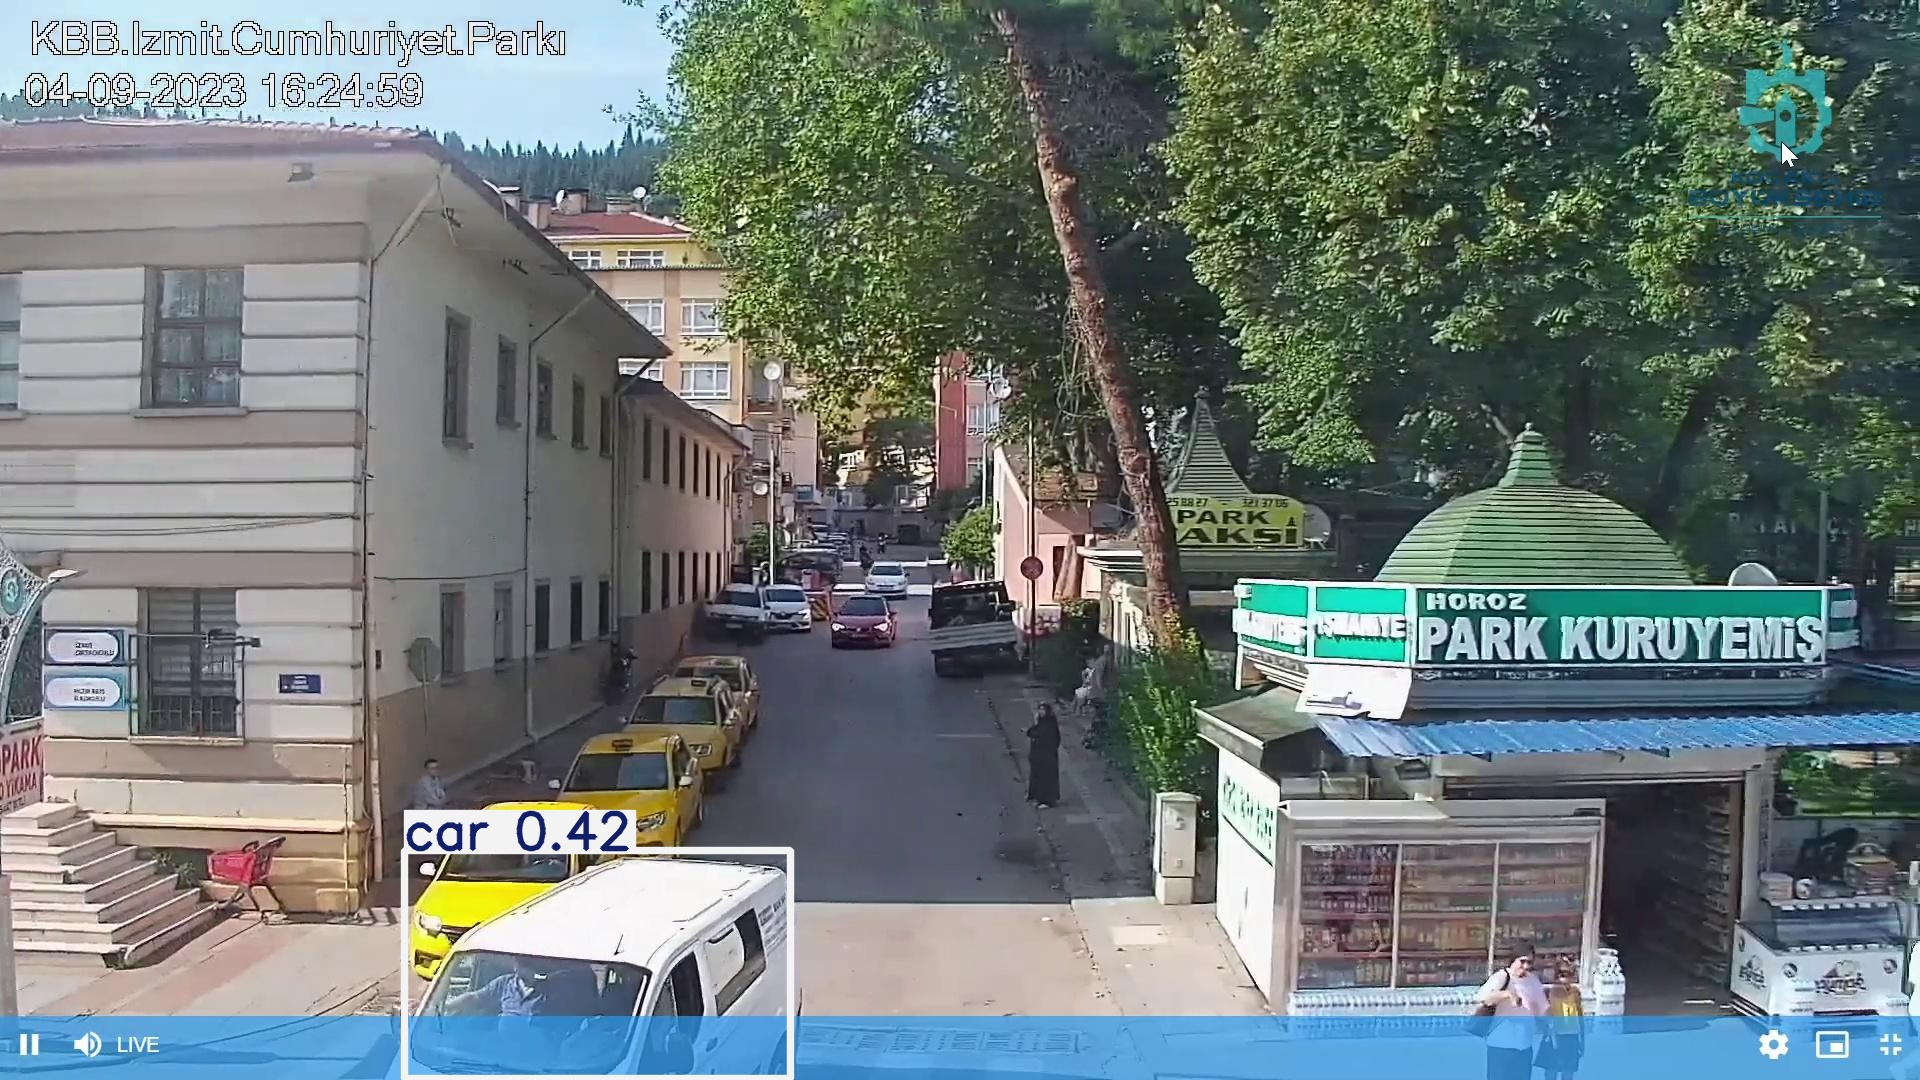

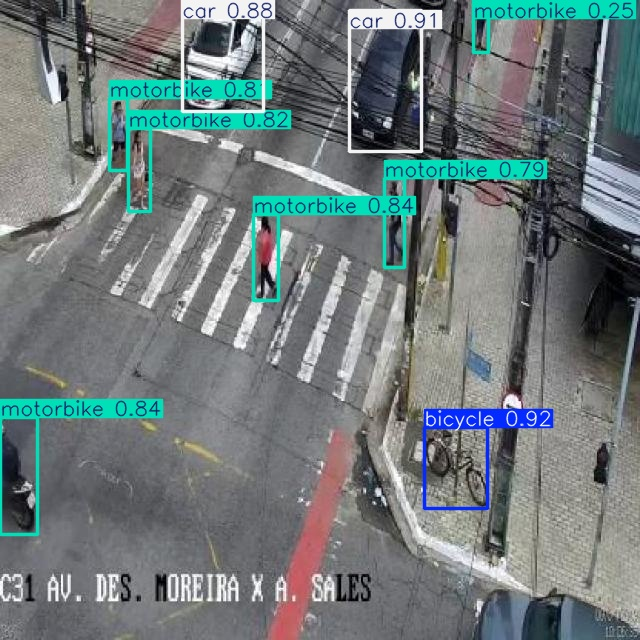

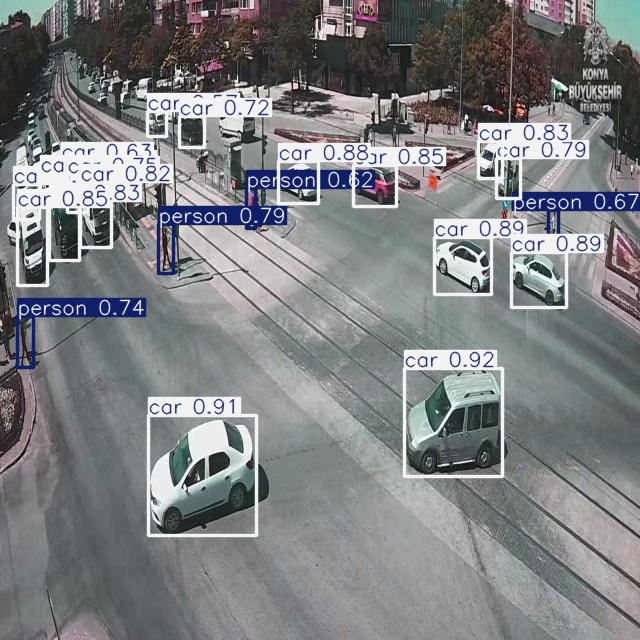

In [ ]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = '/content/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:3]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=600))
    print("\n")

# Copy all the files to google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Create backup folder in your Google Drive
!mkdir -p /content/drive/MyDrive/backup_yolo_project

# Copy important folders/files to Drive
!cp -r /content/datasets /content/drive/MyDrive/backup_yolo_project/
!cp -r /content/runs /content/drive/MyDrive/backup_yolo_project/
!cp -r /content/robustness_tests /content/drive/MyDrive/backup_yolo_project/

# Copy model files separately
!cp /content/yolov8n.pt /content/drive/MyDrive/backup_yolo_project/
!cp /content/yolov8s.pt /content/drive/MyDrive/backup_yolo_project/
